# Dark photon lifetime / proper decay length validation

Validate that the Run-2 (2018) signal samples reproduce their nominal dark-photon **proper
decay length** (c$\tau$), across the full v10 mass x lifetime grid, as a baseline before the
Run-3 (2022/2024) samples (different Pythia version).

**Method (gen level, `SidmProcessor` pipeline, channel `baseNoLj_noTrigger`):** dark photon =
`genAs` ($|\mathrm{pdgId}|=32$); `lxyz` = 3D distance between its production and decay (first-child)
vertices; proper c$\tau$ = `lxyz` / $\beta\gamma$ with $\beta\gamma = p/m$. Two estimators:
- **histogram mean** of the proper-`lxyz` distribution (= floc=0 MLE; equals nominal c$\tau$ where the
  sample is faithful);
- **core-slope fit**: fit the exponential slope on the un-truncated low-x core
  (c$\tau$ = $-1/$slope), which recovers more of the intrinsic c$\tau$ where the generator truncates
  the long-lifetime tail (a lab decay-length cap).

The companion notebook `lifetime_acceptance_correction.ipynb` models that truncation
explicitly to recover the intrinsic c$\tau$ across the whole grid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import lifetime_analysis as la
from sidm.tools import utilities
utilities.set_plot_style()
%matplotlib inline

In [2]:
# Load the full v10 grid (xrdcp'd from lpcmetx EOS if not cached locally) and
# compute the three ctau estimators per sample (mean / core-slope / acceptance-corrected).
output = la.load_grid()
rows, groups, bg_mean = la.compute_grid(output)
print(f"{len(groups)} mass points, {len(rows)} samples, "
      f"<betagamma> in [{min(bg_mean.values()):.0f}, {max(bg_mean.values()):.0f}]")
faithful = [rows[s]['mean']/rows[s]['nominal'] for s in rows if rows[s]['nominal'] <= 1]
print(f"faithful regime (ctau <= 1 cm): median measured/nominal = {np.median(faithful):.3f}  (N={len(faithful)})")

/uscms_data/d3/murtazas/SIDM/sidm/studies/lifetime_study/lifetime_analysis.py:53: RuntimeWarning: invalid value encountered in divide
  effN = np.where(var > 0, vals**2 / var, 0.0)
/uscms_data/d3/murtazas/SIDM/sidm/studies/lifetime_study/lifetime_analysis.py:70: RuntimeWarning: divide by zero encountered in divide
  sig = np.where(effN > 0, 1 / np.sqrt(effN), np.inf)


36 mass points, 179 samples, <betagamma> in [16, 2735]
faithful regime (ctau <= 1 cm): median measured/nominal = 0.994  (N=129)


## Method illustration: one mass point's c$\tau$ scan

The proper-`lxyz` distribution is a clean exponential (flat plateau then fall on log-log); the
core-slope fit (red) tracks it. For long-lifetime samples the data peels **below** the fit at high x
-- the generator's lab decay-length truncation.

/tmp/ipykernel_1538641/4265206350.py:10: RuntimeWarning: divide by zero encountered in divide
  sig = np.where(effN > 0, 1/np.sqrt(effN), np.inf)


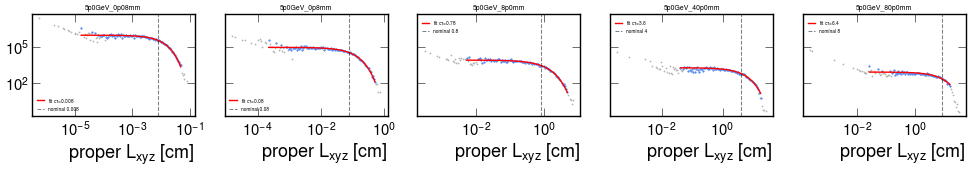

In [3]:
mp = ('4Mu', '500GeV', '5p0GeV')          # one mass point spanning the truncation
samples = groups[mp]
fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 4), sharey=True)
for ax, s in zip(np.atleast_1d(axes), samples):
    c, dens, effN, mean = la.proper_density(output, s)
    ly = np.where(dens > 0, np.log(dens), np.nan); mask = effN >= 5; slope = np.nan
    if mask.sum() >= 4:
        for _ in range(30):
            slope, ic = np.polyfit(c[mask], ly[mask], 1, w=np.sqrt(effN[mask]))
            sig = np.where(effN > 0, 1/np.sqrt(effN), np.inf)
            trim = mask & (ly < ic + slope*c - 3*sig) & (c > np.median(c[mask]))
            if not trim.any(): break
            mask = mask & ~trim
    nm = la.ctau_cm(s)
    ax.plot(c, dens, '.', ms=3, color='0.7')
    ax.plot(c[mask], dens[mask], '.', ms=4, color='C0')
    ax.plot(c[mask], np.exp(ic + slope*c[mask]), 'r-', lw=2, label=fr'fit c$\tau$={-1/slope:.2g}')
    ax.axvline(nm, color='k', ls='--', alpha=.5, label=f'nominal {nm:g}')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_title(s.split('_',2)[-1], fontsize=10)
    ax.set_xlabel(r'proper $L_{xyz}$ [cm]'); ax.legend(fontsize=7)
fig.tight_layout()

## Full-grid validation

Measured / nominal c$\tau$ vs nominal c$\tau$, **one line per mass point, coloured by $\langle\beta\gamma\rangle$**.
The histogram mean (top) is flat at 1 until the generator truncation bites -- with **onset ordered by
boost** (high $\beta\gamma$ truncates earliest). The core-slope fit (bottom) recovers more of the
intrinsic c$\tau$, but a residual remains because the truncation is gradual.

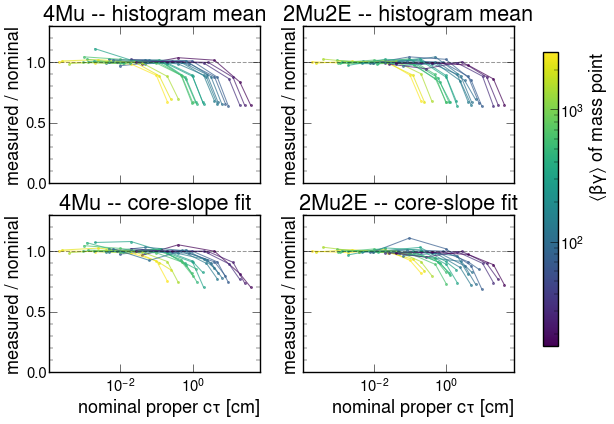

In [4]:
norm = mcolors.LogNorm(min(bg_mean.values()), max(bg_mean.values()))
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True, sharey=True)
for j, ch in enumerate(['4Mu', '2Mu2E']):
    for r, est in enumerate(['mean', 'optionB']):
        ax = axes[r][j]
        for k, ss in groups.items():
            if k[0] != ch: continue
            nom = [rows[s]['nominal'] for s in ss]
            val = [rows[s][est]/rows[s]['nominal'] for s in ss]
            ax.plot(nom, val, '-o', ms=3, color=cm.viridis(norm(bg_mean[k])), alpha=.7)
        ax.axhline(1, color='k', ls='--', alpha=.4); ax.set_xscale('log'); ax.set_ylim(0, 1.3)
        ax.set_title(f"{ch} -- {'histogram mean' if est=='mean' else 'core-slope fit'}")
        ax.set_ylabel('measured / nominal')
        if r == 1: ax.set_xlabel(r'nominal proper c$\tau$ [cm]')
sm = cm.ScalarMappable(norm=norm, cmap='viridis'); sm.set_array([])
fig.colorbar(sm, ax=axes, label=r'$\langle\beta\gamma\rangle$ of mass point', shrink=.85)

## Result

- **Faithful regime (c$\tau \lesssim 1$ cm):** measured c$\tau$ = nominal to sub-percent across the
  whole grid (median measured/nominal $\approx$ 0.99) -- the 2018 samples encode the dark-photon
  lifetime correctly here.
- **Long lifetimes:** the generator caps the **lab** decay length, truncating the exponential tail, so
  the mean reads low with an onset that scales as $R_{\max}/\langle\beta\gamma\rangle$. The core-slope
  fit recovers most of the intrinsic c$\tau$; the acceptance correction recovers it fully.
- The same machinery points at the Run-3 samples by swapping the location YAML / ntuple tag.